# Unit-2 MLOps Practical: Complete MLflow Workflow

**Dataset:** Kidney Disease Classification

**Complete Unit-2 MLflow workflow:**  
**Experiment Tracking → Hyperparameter Tuning → Model Versioning → Model Registry → Model Alias → Load & Predict**

---

## 🎯 Learning Objectives

By completing this practical, students will be able to:

1. Understand why experiment tracking is required in MLOps.
2. Create and manage an MLflow experiment and multiple runs.
3. Log **parameters, metrics, and artifacts**.
4. Compare multiple machine-learning experiments.
5. Perform **automated hyperparameter tuning** using `GridSearchCV`.
6. Track the tuning experiment and its best configuration in MLflow.
7. Understand the difference between an **MLflow Run** and a **Model Version**.
8. Register a trained model in the **MLflow Model Registry**.
9. Create and use a modern MLflow **model alias** such as `champion`.
10. Load a registered model and use it for prediction.
11. Understand a complete model-management workflow in MLOps.

> **Important:** This notebook is designed for learning MLOps concepts. The reported model performance is for demonstration only and should not be interpreted as clinical or real-world medical performance.


## 1. Prerequisites

Before running this notebook:

### Install required packages

Run in Anaconda Prompt / Terminal:

```bash
conda activate feast_lab
python -m pip install mlflow scikit-learn pandas matplotlib seaborn joblib
```

Verify MLflow:

```bash
mlflow --version
```

### Start the MLflow tracking + registry server

For this complete practical, use an MLflow server so that **Tracking and Model Registry** are available from the same URI.

Example:

```bash
cd C:\Users\Admin\MLflow
mlflow server --host 127.0.0.1 --port 5000 --backend-store-uri sqlite:///mlflow.db --default-artifact-root ./mlartifacts
```

Then open:

```text
http://127.0.0.1:5000
```

> If you already have your MLflow server running on port 5000, do not start a second server.

### Recommended project structure

```text
MLOps_MLflow_Unit2/
│
├── Unit-2_MLflow_Complete_Practical.ipynb
├── kidney_disease_cleaned.csv
└── MLflow server storage
```

### Important distinction

```text
MLflow Tracking
      ↓
Experiments → Runs → Parameters / Metrics / Artifacts

MLflow Model Registry
      ↓
Registered Model → Model Versions → Alias
```


## 2. MLflow Concepts — The Big Picture

MLflow helps us keep track of ML experiments.

```text
                    MLflow Experiment
                           │
          ┌────────────────┼────────────────┐
          ↓                ↓                ↓
        Run 1            Run 2            Run 3
          │                │                │
     Parameters        Parameters       Parameters
     Metrics           Metrics          Metrics
     Artifacts         Artifacts        Artifacts
```

### Remember

| Concept | Simple meaning |
|---|---|
| **Experiment** | A collection of related ML runs |
| **Run** | One execution of an ML experiment |
| **Parameter** | A value/configuration we choose |
| **Metric** | A value measured after the model runs |
| **Artifact** | A file produced by the experiment |

### The key questions

- **Parameter:** What did I configure?
- **Metric:** How well did it perform?
- **Artifact:** What file did I produce?
- **Run:** What happened in this particular execution?

## 3. Import Libraries

We use:

- **pandas / NumPy** for data handling
- **scikit-learn** for preprocessing and models
- **matplotlib / seaborn** for visualizations
- **MLflow** for experiment tracking

The preprocessing is included inside the scikit-learn pipeline so that students can focus on the MLflow workflow.

In [1]:
# ============================================
# CELL 1: IMPORT LIBRARIES
# ============================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")
print("MLflow version:", mlflow.__version__)

Libraries imported successfully.
MLflow version: 3.15.1


## 4. Load the Dataset

We use the cleaned kidney disease dataset.

> **File requirement:** Keep `kidney_disease_cleaned.csv` in the same folder as this notebook.

The target column is:

```text
classification
```

The `id` column is removed later because it is an identifier rather than a useful predictive feature.

In [2]:
# ============================================
# CELL 2: LOAD DATASET
# ============================================

DATA_FILE = "kidney_disease_cleaned.csv"

df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (400, 26)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


## 5. Basic Dataset Check

Before training a model, inspect:

- dataset size
- column names
- missing values
- data types

This is not the main focus of the MLflow lab; it simply prepares the dataset for model training.

In [3]:
# ============================================
# CELL 3: BASIC DATASET INFORMATION
# ============================================

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(400, 26)

Columns:
['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Missing Values:
id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

Data Types:
id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc       

## 6. Separate Features and Target

The target is `classification`.

```text
X → input features
y → target/output
```

We will train models using `X_train` and `y_train`, and evaluate them using `X_test` and `y_test`.

In [4]:
# ============================================
# CELL 4: SEPARATE FEATURES AND TARGET
# ============================================

X = df.drop("classification", axis=1)
y = df["classification"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(y.value_counts())

Features shape: (400, 25)
Target shape: (400,)

Target classes:
classification
ckd       250
notckd    150
Name: count, dtype: int64


## 7. Remove the ID Column

The `id` column identifies a record. It should not normally be treated as a predictive feature.

```text
id → identifier
age, bp, sg, ... → features
classification → target
```

In [5]:
# ============================================
# CELL 5: REMOVE ID COLUMN
# ============================================

if "id" in X.columns:
    X = X.drop("id", axis=1)
    print("ID column removed.")
else:
    print("ID column not found.")

print("\nRemaining feature columns:")
print(X.columns.tolist())

ID column removed.

Remaining feature columns:
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


## 8. Identify Numerical and Categorical Features

Different types of data require different preprocessing:

- **Numerical:** imputation + scaling
- **Categorical:** imputation + one-hot encoding

This preprocessing will be included in every model pipeline.

In [6]:
# ============================================
# CELL 6: IDENTIFY COLUMN TYPES
# ============================================

numeric_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']

Categorical columns:
['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


## 9. Create the Preprocessing Pipeline

### Numerical pipeline

```text
Missing values → Mean imputation → Standardization
```

### Categorical pipeline

```text
Missing values → Most-frequent imputation → One-hot encoding
```

Using a pipeline prevents us from manually repeating preprocessing for every model.

In [7]:
# ============================================
# CELL 7: PREPROCESSING PIPELINE
# ============================================

# Numerical features:
# 1. Fill missing values using the mean.
# 2. Standardize the numerical values.
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Categorical features:
# 1. Fill missing values using the most frequent value.
# 2. Convert categories into numerical one-hot encoded columns.
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing pipelines.
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## 10. Train-Test Split

We use:

- **80%** for training
- **20%** for testing
- `random_state=42` for reproducibility
- `stratify=y` to preserve the class distribution

In [8]:
# ============================================
# CELL 8: TRAIN-TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 320
Testing samples: 80


# PART A — BASIC MLFLOW

## 11. Configure the MLflow Experiment

An **experiment** groups related runs.

We will create:

```text
Kidney Disease Classification
```

Inside this experiment we will create multiple runs:

```text
Run 1 → Logistic Regression
Run 2 → Logistic Regression with a different C
Run 3 → Random Forest
Run 4 → Decision Tree
Run 5 → SVM
```

This allows us to compare experiments systematically.

In [9]:
# ============================================
# CELL 9: CONFIGURE MLFLOW
# ============================================

import mlflow

EXPERIMENT_NAME = "Unit-2-Kidney Disease Classification"

# Connect the notebook to the MLflow server
MLFLOW_SERVER = "http://127.0.0.1:5000"

mlflow.set_tracking_uri(MLFLOW_SERVER)

# Also configure the Model Registry
mlflow.set_registry_uri(MLFLOW_SERVER)

# Create the experiment if it does not exist,
# otherwise select the existing experiment.
mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow experiment selected:")
print(EXPERIMENT_NAME)

print("\nMLflow Tracking URI:")
print(mlflow.get_tracking_uri())

print("\nMLflow Registry URI:")
print(mlflow.get_registry_uri())

2026/09/08 10:47:13 INFO mlflow.tracking.fluent: Experiment with name 'Unit-2-Kidney Disease Classification' does not exist. Creating a new experiment.


MLflow experiment selected:
Unit-2-Kidney Disease Classification

MLflow Tracking URI:
http://127.0.0.1:5000

MLflow Registry URI:
http://127.0.0.1:5000


## 12. Create the First Model — Logistic Regression

We start with a simple baseline model.

The model pipeline contains:

```text
Preprocessing
     ↓
Logistic Regression
```

The parameter `C` controls the regularization strength used by Logistic Regression.

We will record `C` in MLflow so we can later compare different configurations.

In [10]:
# ============================================
# CELL 10: LOGISTIC REGRESSION MODEL
# ============================================

model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        C=1.0,
        max_iter=1000
    ))
])

print(model)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bp', 'sg', 'al',
                                                   'su', 'bgr', 'bu', 'sc',
                                                   'sod', 'pot', 'hemo']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                    

## 13. First MLflow Run — Parameters + Metrics

This is the most important MLflow cell.

### What are we logging?

**Parameters**

```text
model
C
test_size
random_state
```

**Metrics**

```text
accuracy
precision
recall
f1_score
```

### Important

`mlflow.start_run()` creates one MLflow **Run**.

Everything logged inside the `with` block belongs to that run.

In [11]:
# ============================================
# CELL 11: FIRST MLFLOW RUN
# ============================================

with mlflow.start_run(
    run_name="Logistic Regression - Run 1"
):

    # ----------------------------------------
    # PARAMETERS
    # What did we configure?
    # ----------------------------------------

    mlflow.log_params({
        "model": "Logistic Regression",
        "C": 1.0,
        "test_size": 0.20,
        "random_state": 42
    })

    # ----------------------------------------
    # TRAIN
    # ----------------------------------------

    model.fit(X_train, y_train)

    # ----------------------------------------
    # PREDICT
    # ----------------------------------------

    predictions = model.predict(X_test)

    # ----------------------------------------
    # CALCULATE METRICS
    # What did we measure?
    # ----------------------------------------

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    # ----------------------------------------
    # LOG METRICS
    # ----------------------------------------

    mlflow.log_metrics({
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

    print("Model: Logistic Regression")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

Model: Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
🏃 View run Logistic Regression - Run 1 at: http://127.0.0.1:5000/#/experiments/4/runs/9731208f15044a97a35d4de3f320bbb4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


### 🔎 Check the MLflow UI

Refresh the MLflow browser.

Go to:

```text
Kidney Disease Classification
        ↓
Runs
        ↓
Logistic Regression - Run 1
```

Look at:

- **Parameters**
- **Metrics**

### Student question

> What is the difference between a parameter and a metric?

**Answer:**

- Parameter → value/configuration chosen for the experiment.
- Metric → performance value measured after execution.

# PART B — COMPLETE TRACKING

## 14. Second Run — Change a Parameter

Now we change only:

```text
C = 0.1
```

This creates a new run.

The purpose is to demonstrate that MLflow keeps the two experiments separately, making comparison possible.

In [12]:
# ============================================
# CELL 12: LOGISTIC REGRESSION - RUN 2
# ============================================

model_2 = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        C=0.1,
        max_iter=1000
    ))
])

with mlflow.start_run(
    run_name="Logistic Regression - Run 2"
):

    # Log the configuration used in this run.
    mlflow.log_params({
        "model": "Logistic Regression",
        "C": 0.1,
        "test_size": 0.20,
        "random_state": 42
    })

    # Train the model.
    model_2.fit(X_train, y_train)

    # Generate predictions.
    predictions_2 = model_2.predict(X_test)

    # Calculate evaluation metrics.
    accuracy_2 = accuracy_score(y_test, predictions_2)

    precision_2 = precision_score(
        y_test,
        predictions_2,
        average="weighted"
    )

    recall_2 = recall_score(
        y_test,
        predictions_2,
        average="weighted"
    )

    f1_2 = f1_score(
        y_test,
        predictions_2,
        average="weighted"
    )

    # Log all metrics to this run.
    mlflow.log_metrics({
        "accuracy": accuracy_2,
        "precision": precision_2,
        "recall": recall_2,
        "f1_score": f1_2
    })

    print("Accuracy :", accuracy_2)
    print("Precision:", precision_2)
    print("Recall   :", recall_2)
    print("F1 Score :", f1_2)

Accuracy : 0.9875
Precision: 0.9877450980392156
Recall   : 0.9875
F1 Score : 0.987455948984729
🏃 View run Logistic Regression - Run 2 at: http://127.0.0.1:5000/#/experiments/4/runs/933961c65f594b5aa801e7437430fe4c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


## 15. Compare the Two Logistic Regression Runs

In the MLflow UI, compare:

```text
Run 1 → C = 1.0
Run 2 → C = 0.1
```

Ask students:

> **Did changing the parameter change the performance?**

This is the basic idea behind experiment tracking and later leads naturally to **hyperparameter tuning**.

## 16. Create an Artifact — Confusion Matrix

An **artifact** is a file produced by an ML experiment.

Examples:

- confusion matrix image
- classification report
- CSV file
- trained model
- feature importance plot

Here we create a confusion matrix image.

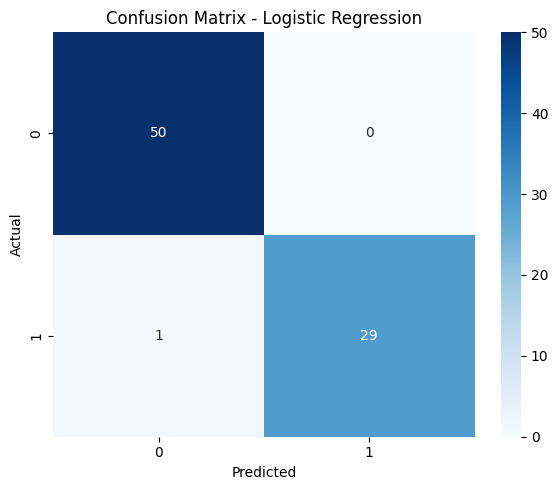

In [13]:
# ============================================
# CELL 13: CREATE CONFUSION MATRIX
# ============================================

# Create a confusion matrix using the predictions
# from Logistic Regression Run 2.
cm = confusion_matrix(
    y_test,
    predictions_2
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

# Save the figure as a file.
# This file will become an MLflow artifact.
plt.savefig(
    "confusion_matrix.png",
    dpi=300
)

plt.show()

### What happened?

We now have a physical file:

```text
confusion_matrix.png
```

But simply creating the file does **not** put it into MLflow.

We must explicitly log it using:

```python
mlflow.log_artifact("confusion_matrix.png")
```

In [14]:
# ============================================
# CELL 14: CREATE CLASSIFICATION REPORT
# ============================================

# Generate a text report containing
# precision, recall, F1-score and support.
report = classification_report(
    y_test,
    predictions_2
)

print(report)

# Save the report as a text file.
with open(
    "classification_report.txt",
    "w"
) as file:
    file.write(report)

print("Classification report saved.")

              precision    recall  f1-score   support

         ckd       0.98      1.00      0.99        50
      notckd       1.00      0.97      0.98        30

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80

Classification report saved.


## 17. Complete Tracking Run — Parameters + Metrics + Artifacts

This run demonstrates the complete tracking concept.

```text
                 MLflow Run
                     │
       ┌─────────────┼─────────────┐
       ↓             ↓             ↓
 Parameters       Metrics       Artifacts
       ↓             ↓             ↓
      C            Accuracy       PNG
    test_size      Precision      TXT
   random_state    Recall
                   F1
```

In [15]:
# ============================================
# CELL 15: COMPLETE TRACKING RUN
# ============================================

with mlflow.start_run(
    run_name="Logistic Regression - Complete Tracking"
):

    # -------------------------------
    # PARAMETERS
    # -------------------------------

    mlflow.log_params({
        "model": "Logistic Regression",
        "C": 0.1,
        "test_size": 0.20,
        "random_state": 42
    })

    # -------------------------------
    # METRICS
    # -------------------------------

    mlflow.log_metrics({
        "accuracy": accuracy_2,
        "precision": precision_2,
        "recall": recall_2,
        "f1_score": f1_2
    })

    # -------------------------------
    # ARTIFACTS
    # -------------------------------

    mlflow.log_artifact(
        "confusion_matrix.png"
    )

    mlflow.log_artifact(
        "classification_report.txt"
    )

    print("Complete MLflow run logged successfully.")

Complete MLflow run logged successfully.
🏃 View run Logistic Regression - Complete Tracking at: http://127.0.0.1:5000/#/experiments/4/runs/2c13c6dca63449ac9be22bf38a33a2d4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


### 🔎 Check the MLflow UI again

Open:

```text
Logistic Regression - Complete Tracking
```

Now the run should contain:

```text
Parameters
├── model
├── C
├── test_size
└── random_state

Metrics
├── accuracy
├── precision
├── recall
└── f1_score

Artifacts
├── confusion_matrix.png
└── classification_report.txt
```

> **Key lesson:** `mlflow.log_param()`, `mlflow.log_metric()`, and `mlflow.log_artifact()` control what is stored with the run.

# PART C — COMPARE EXPERIMENTS

## 18. Train Multiple Models

Now we will track different algorithms as separate MLflow runs:

1. Logistic Regression
2. Random Forest
3. Decision Tree
4. SVM

The objective is not to find the clinically best model. The objective is to learn how MLflow helps us **record and compare different experiments**.

In [16]:
# ============================================
# CELL 16: RANDOM FOREST
# ============================================

rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ))
])

with mlflow.start_run(
    run_name="Random Forest"
):

    # Parameters
    mlflow.log_params({
        "model": "Random Forest",
        "n_estimators": 100,
        "max_depth": 10,
        "random_state": 42,
        "test_size": 0.20
    })

    # Train
    rf_model.fit(X_train, y_train)

    # Predict
    rf_predictions = rf_model.predict(X_test)

    # Metrics
    rf_accuracy = accuracy_score(y_test, rf_predictions)

    rf_precision = precision_score(
        y_test,
        rf_predictions,
        average="weighted"
    )

    rf_recall = recall_score(
        y_test,
        rf_predictions,
        average="weighted"
    )

    rf_f1 = f1_score(
        y_test,
        rf_predictions,
        average="weighted"
    )

    # Log metrics
    mlflow.log_metrics({
        "accuracy": rf_accuracy,
        "precision": rf_precision,
        "recall": rf_recall,
        "f1_score": rf_f1
    })

    print("Random Forest")
    print("Accuracy :", rf_accuracy)
    print("Precision:", rf_precision)
    print("Recall   :", rf_recall)
    print("F1 Score :", rf_f1)

Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
🏃 View run Random Forest at: http://127.0.0.1:5000/#/experiments/4/runs/7f84374065264f4689949fd4968baf5f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


In [17]:
# ============================================
# CELL 17: DECISION TREE
# ============================================

dt_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

with mlflow.start_run(
    run_name="Decision Tree"
):

    # Parameters
    mlflow.log_params({
        "model": "Decision Tree",
        "max_depth": 5,
        "random_state": 42,
        "test_size": 0.20
    })

    # Train
    dt_model.fit(X_train, y_train)

    # Predict
    dt_predictions = dt_model.predict(X_test)

    # Metrics
    dt_accuracy = accuracy_score(y_test, dt_predictions)

    dt_precision = precision_score(
        y_test,
        dt_predictions,
        average="weighted"
    )

    dt_recall = recall_score(
        y_test,
        dt_predictions,
        average="weighted"
    )

    dt_f1 = f1_score(
        y_test,
        dt_predictions,
        average="weighted"
    )

    # Log metrics
    mlflow.log_metrics({
        "accuracy": dt_accuracy,
        "precision": dt_precision,
        "recall": dt_recall,
        "f1_score": dt_f1
    })

    print("Decision Tree")
    print("Accuracy :", dt_accuracy)
    print("Precision:", dt_precision)
    print("Recall   :", dt_recall)
    print("F1 Score :", dt_f1)

Decision Tree
Accuracy : 0.95
Precision: 0.9505494505494505
Recall   : 0.95
F1 Score : 0.9496281271129142
🏃 View run Decision Tree at: http://127.0.0.1:5000/#/experiments/4/runs/b00a281b527a4a1eb71f3d1747ca2f4c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


In [18]:
# ============================================
# CELL 18: SUPPORT VECTOR MACHINE (SVM)
# ============================================

svm_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", SVC(
        C=1.0,
        kernel="rbf"
    ))
])

with mlflow.start_run(
    run_name="SVM"
):

    # Parameters
    mlflow.log_params({
        "model": "SVM",
        "C": 1.0,
        "kernel": "rbf",
        "test_size": 0.20
    })

    # Train
    svm_model.fit(X_train, y_train)

    # Predict
    svm_predictions = svm_model.predict(X_test)

    # Metrics
    svm_accuracy = accuracy_score(y_test, svm_predictions)

    svm_precision = precision_score(
        y_test,
        svm_predictions,
        average="weighted"
    )

    svm_recall = recall_score(
        y_test,
        svm_predictions,
        average="weighted"
    )

    svm_f1 = f1_score(
        y_test,
        svm_predictions,
        average="weighted"
    )

    # Log metrics
    mlflow.log_metrics({
        "accuracy": svm_accuracy,
        "precision": svm_precision,
        "recall": svm_recall,
        "f1_score": svm_f1
    })

    print("SVM")
    print("Accuracy :", svm_accuracy)
    print("Precision:", svm_precision)
    print("Recall   :", svm_recall)
    print("F1 Score :", svm_f1)

SVM
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
🏃 View run SVM at: http://127.0.0.1:5000/#/experiments/4/runs/8af533df36464208a5b376847f7a5041
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


## 19. Create a Model Comparison Table

MLflow is the main experiment tracking tool. We also create a simple pandas table so students can understand the same comparison programmatically.

Later, the same information can be compared directly inside the MLflow UI.

In [19]:
# ============================================
# CELL 19: COMPARE MODELS
# ============================================

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree",
        "SVM"
    ],
    "Accuracy": [
        accuracy_2,
        rf_accuracy,
        dt_accuracy,
        svm_accuracy
    ],
    "Precision": [
        precision_2,
        rf_precision,
        dt_precision,
        svm_precision
    ],
    "Recall": [
        recall_2,
        rf_recall,
        dt_recall,
        svm_recall
    ],
    "F1 Score": [
        f1_2,
        rf_f1,
        dt_f1,
        svm_f1
    ]
})

comparison = comparison.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,1.0000,1.000000,1.0000,1.000000
1,SVM,1.0000,1.000000,1.0000,1.000000
2,Logistic Regression,0.9875,0.987745,0.9875,0.987456
3,Decision Tree,0.9500,0.950549,0.9500,0.949628


## 20. Save the Comparison Table as an Artifact

A CSV file generated by an experiment is also an **artifact**.

We save:

```text
model_comparison.csv
```

and then log it to MLflow.

In [20]:
# ============================================
# CELL 20: SAVE MODEL COMPARISON
# ============================================

comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved as model_comparison.csv")

Model comparison saved as model_comparison.csv


In [21]:
# ============================================
# CELL 21: LOG COMPARISON ARTIFACT
# ============================================

best_row = comparison.iloc[0]

with mlflow.start_run(
    run_name="Model Comparison Summary"
):

    # Dataset and experiment information
    mlflow.log_params({
        "dataset": DATA_FILE,
        "models_compared": 4
    })

    # Log the best observed values from this classroom experiment.
    mlflow.log_metrics({
        "best_accuracy": float(best_row["Accuracy"]),
        "best_f1_score": float(best_row["F1 Score"])
    })

    # Log the complete comparison table.
    mlflow.log_artifact(
        "model_comparison.csv"
    )

    print("Best model:", best_row["Model"])
    print("Comparison artifact logged.")

Best model: Random Forest
Comparison artifact logged.
🏃 View run Model Comparison Summary at: http://127.0.0.1:5000/#/experiments/4/runs/2b00f4340702420fad57c8dfb3c3ae07
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


## 21. Log the Best Model

Now we demonstrate MLflow model logging.

This is different from:

```python
mlflow.log_artifact("model.pkl")
```

`mlflow.sklearn.log_model()` logs the trained scikit-learn model using the MLflow scikit-learn model flavor.

### Classroom note

We use `cloudpickle` here because the installed MLflow version may use `skops` by default and can request trusted types for some pipelines. `cloudpickle` is convenient for this classroom demonstration, but serialized Python objects should only be loaded from trusted sources.

> **Model Registry is covered in Parts F–G of this complete Unit-2 practical.**

In [22]:
# ============================================
# CELL 22: SELECT AND LOG THE BEST MODEL
# ============================================

best_model_name = best_row["Model"]

# Select the already-trained model object.
if best_model_name == "Logistic Regression":
    best_model = model_2

elif best_model_name == "Random Forest":
    best_model = rf_model

elif best_model_name == "Decision Tree":
    best_model = dt_model

else:
    best_model = svm_model


with mlflow.start_run(
    run_name="Best Model - Final"
):

    # Identify the selected model.
    mlflow.log_param(
        "selected_model",
        best_model_name
    )

    # Log its evaluation results.
    mlflow.log_metrics({
        "accuracy": float(best_row["Accuracy"]),
        "precision": float(best_row["Precision"]),
        "recall": float(best_row["Recall"]),
        "f1_score": float(best_row["F1 Score"])
    })

    # Log the model using the MLflow scikit-learn flavor.
    # cloudpickle is used here for compatibility with this
    # classroom environment.
    mlflow.sklearn.log_model(
        sk_model=best_model,
        name="kidney_disease_model",
        serialization_format="cloudpickle"
    )

    print("Best model logged successfully!")
    print("Model:", best_model_name)

2026/09/08 10:49:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best model logged successfully!
Model: Random Forest
🏃 View run Best Model - Final at: http://127.0.0.1:5000/#/experiments/4/runs/f69be15bccbb4351bd668eff39251522
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


## 22. Final Result

Let's display the final model comparison.

**Important:** The highest score in this notebook is only the result of this particular train/test split and configuration. Students should not treat it as a general claim about model quality.

In [23]:
# ============================================
# CELL 23: FINAL MODEL COMPARISON
# ============================================

print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

display(comparison)

print("\nBest Model:")
print(best_row["Model"])

print("\nBest Accuracy:")
print(best_row["Accuracy"])

print("\nBest F1 Score:")
print(best_row["F1 Score"])

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,1.0000,1.000000,1.0000,1.000000
1,SVM,1.0000,1.000000,1.0000,1.000000
2,Logistic Regression,0.9875,0.987745,0.9875,0.987456
3,Decision Tree,0.9500,0.950549,0.9500,0.949628



Best Model:
Random Forest

Best Accuracy:
1.0

Best F1 Score:
1.0


# PART D — HYPERPARAMETER TUNING

## 24. Why Hyperparameter Tuning?

So far, we manually changed parameters such as:

```text
C = 1.0
C = 0.1
```

and created separate MLflow runs.

That is useful for understanding experiment tracking, but it is **manual experimentation**.

Now we automate the search.

### Hyperparameter tuning workflow

```text
Candidate Hyperparameters
          ↓
     GridSearchCV
          ↓
      Cross-Validation
          ↓
   Best Configuration
          ↓
     Test Evaluation
          ↓
      MLflow Run
```

### Important

A **hyperparameter** is selected before/during training, for example:

```text
C
solver
n_estimators
max_depth
```

A **metric** is measured after training, for example:

```text
accuracy
precision
recall
F1-score
```


In [24]:
# ============================================
# CELL D1: DEFINE HYPERPARAMETER SEARCH
# ============================================

# We tune Logistic Regression using the SAME preprocessing
# pipeline already defined earlier in this notebook.

tuning_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000
    ))
])

# Because the model step is named "model", the parameters
# must be written using the prefix "model__".
param_grid = {
    "model__C": [0.01, 0.1, 1.0, 10.0],
    "model__solver": ["lbfgs", "liblinear"]
}

print("Hyperparameter grid:")
print(param_grid)


Hyperparameter grid:
{'model__C': [0.01, 0.1, 1.0, 10.0], 'model__solver': ['lbfgs', 'liblinear']}


In [25]:
# ============================================
# CELL D2: RUN GRIDSEARCHCV
# ============================================

# GridSearchCV automatically:
# 1. Tries every parameter combination.
# 2. Performs 5-fold cross-validation.
# 3. Selects the configuration with the best weighted F1-score.

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(grid_search.best_score_)


Best parameters:
{'model__C': 0.01, 'model__solver': 'lbfgs'}

Best cross-validation F1-score:
0.9906352639907846


In [26]:
# ============================================
# CELL D3: EVALUATE THE TUNED MODEL
# ============================================

tuned_model = grid_search.best_estimator_

tuned_predictions = tuned_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_predictions)

tuned_precision = precision_score(
    y_test,
    tuned_predictions,
    average="weighted"
)

tuned_recall = recall_score(
    y_test,
    tuned_predictions,
    average="weighted"
)

tuned_f1 = f1_score(
    y_test,
    tuned_predictions,
    average="weighted"
)

print("Tuned Logistic Regression")
print("-------------------------")
print("Best Parameters:", grid_search.best_params_)
print("CV F1 Score    :", grid_search.best_score_)
print("Test Accuracy  :", tuned_accuracy)
print("Test Precision :", tuned_precision)
print("Test Recall    :", tuned_recall)
print("Test F1 Score  :", tuned_f1)


Tuned Logistic Regression
-------------------------
Best Parameters: {'model__C': 0.01, 'model__solver': 'lbfgs'}
CV F1 Score    : 0.9906352639907846
Test Accuracy  : 0.9875
Test Precision : 0.9877450980392156
Test Recall    : 0.9875
Test F1 Score  : 0.987455948984729


In [27]:
# ============================================
# CELL D4: TRACK THE TUNING EXPERIMENT IN MLFLOW
# ============================================

# This is important:
# GridSearchCV performs the search, while MLflow records
# the final tuning configuration and its results.

with mlflow.start_run(
    run_name="Logistic Regression - GridSearchCV"
) as tuning_run:

    tuning_run_id = tuning_run.info.run_id

    # General tuning information
    mlflow.log_params({
        "model": "Logistic Regression",
        "tuning_method": "GridSearchCV",
        "cv_folds": 5,
        "scoring": "f1_weighted",
        "test_size": 0.20,
        "random_state": 42
    })

    # Log the selected/best hyperparameters
    mlflow.log_params({
        "best_C": float(grid_search.best_params_["model__C"]),
        "best_solver": grid_search.best_params_["model__solver"]
    })

    # Log cross-validation and test metrics
    mlflow.log_metrics({
        "best_cv_f1_weighted": float(grid_search.best_score_),
        "test_accuracy": float(tuned_accuracy),
        "test_precision": float(tuned_precision),
        "test_recall": float(tuned_recall),
        "f1_score": float(tuned_f1)
    })

    # Log the tuned model.
    # cloudpickle is used for compatibility with the classroom
    # environment and the existing notebook workflow.
    mlflow.sklearn.log_model(
        sk_model=tuned_model,
        name="tuned_logistic_regression",
        serialization_format="cloudpickle"
    )

    print("Tuning run logged successfully.")
    print("Run ID:", tuning_run_id)


2026/09/08 10:51:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tuning run logged successfully.
Run ID: 06cb393736344849bf0ed37adf2a57d5
🏃 View run Logistic Regression - GridSearchCV at: http://127.0.0.1:5000/#/experiments/4/runs/06cb393736344849bf0ed37adf2a57d5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


## 25. Interpret the Tuning Result

The important distinction is:

```text
GridSearchCV
    ↓
Searches hyperparameter combinations
    ↓
Selects best configuration using CV
    ↓
MLflow
    ↓
Records the selected configuration and results
```

**Do not confuse:**

- `GridSearchCV` → performs the search.
- MLflow → tracks the experiment and selected result.
- Model Registry → manages deployable model versions.


# PART E — MODEL VERSIONING

## 26. Run vs Model Version

This is one of the most important concepts in MLOps.

### MLflow Run

A **Run** represents one execution of an experiment.

Example:

```text
Run A
  C = 0.1
  F1 = 0.91

Run B
  C = 1.0
  F1 = 0.93
```

### Model Version

A **Model Version** is a registered snapshot of a model under a registered model name.

```text
Registered Model
       │
       ├── Version 1
       ├── Version 2
       └── Version 3
```

Therefore:

> **Multiple MLflow runs are NOT automatically model versions.**

A model becomes a **model version** when a logged model is registered under a registered model name.


In [28]:
# ============================================
# CELL E1: REGISTER THE FINAL MODEL
# ============================================

REGISTERED_MODEL_NAME = "KidneyDiseaseClassifier"

# The "Best Model - Final" run created earlier contains
# the selected model from the original model comparison.
#
# We find that run from the experiment so that this cell
# remains reusable even when the notebook is rerun.

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

best_final_runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.mlflow.runName = 'Best Model - Final'",
    order_by=["start_time DESC"],
    max_results=1
)

if best_final_runs.empty:
    raise RuntimeError(
        "Best Model - Final run was not found. "
        "Run the earlier model comparison/model logging cells first."
    )

final_run_id = best_final_runs.iloc[0]["run_id"]

final_model_uri = f"runs:/{final_run_id}/kidney_disease_model"

print("Final model run ID:", final_run_id)
print("Final model URI:", final_model_uri)

# Register the logged model.
final_registration = mlflow.register_model(
    model_uri=final_model_uri,
    name=REGISTERED_MODEL_NAME
)

print("\nRegistered model:", REGISTERED_MODEL_NAME)
print("Created model version:", final_registration.version)


Final model run ID: f69be15bccbb4351bd668eff39251522
Final model URI: runs:/f69be15bccbb4351bd668eff39251522/kidney_disease_model


Successfully registered model 'KidneyDiseaseClassifier'.
2026/09/08 10:53:04 WARNING mlflow.tracking._model_registry.fluent: Run with id f69be15bccbb4351bd668eff39251522 has no artifacts at artifact path 'kidney_disease_model', registering model based on models:/m-3c60f883d9aa44109af3ec8aecd72e27 instead
2026/09/08 10:53:04 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: KidneyDiseaseClassifier, version 1
Created version '1' of model 'KidneyDiseaseClassifier'.



Registered model: KidneyDiseaseClassifier
Created model version: 1


In [29]:
# ============================================
# CELL E2: REGISTER THE TUNED MODEL AS ANOTHER VERSION
# ============================================

# Register the tuned model under the SAME registered model name.
# MLflow automatically assigns the next version number.

tuned_model_uri = f"runs:/{tuning_run_id}/tuned_logistic_regression"

tuned_registration = mlflow.register_model(
    model_uri=tuned_model_uri,
    name=REGISTERED_MODEL_NAME
)

print("Tuned model registered successfully.")
print("Created model version:", tuned_registration.version)


Registered model 'KidneyDiseaseClassifier' already exists. Creating a new version of this model...
2026/09/08 10:53:29 WARNING mlflow.tracking._model_registry.fluent: Run with id 06cb393736344849bf0ed37adf2a57d5 has no artifacts at artifact path 'tuned_logistic_regression', registering model based on models:/m-da4c31df74e84d91b60a3e8d61642264 instead
2026/09/08 10:53:29 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: KidneyDiseaseClassifier, version 2


Tuned model registered successfully.
Created model version: 2


Created version '2' of model 'KidneyDiseaseClassifier'.


## 27. What Just Happened?

The workflow is now:

```text
Experiment
   │
   ├── Run: Random Forest
   ├── Run: Decision Tree
   ├── Run: SVM
   ├── Run: Best Model - Final
   └── Run: GridSearchCV
                    │
                    ↓
             Logged Models
                    │
                    ↓
        KidneyDiseaseClassifier
                    │
             ┌──────┴──────┐
             ↓             ↓
          Version 1      Version 2
```

The exact version numbers can be different when you rerun the notebook because MLflow automatically increments model versions.


In [30]:
# ============================================
# CELL E3: LIST MODEL VERSIONS
# ============================================

from mlflow import MlflowClient

client = MlflowClient()

model_versions = client.search_model_versions(
    f"name='{REGISTERED_MODEL_NAME}'"
)

version_rows = []

for mv in model_versions:
    run = client.get_run(mv.run_id)

    version_rows.append({
        "version": mv.version,
        "run_id": mv.run_id,
        "status": mv.status,
        "source": mv.source,
        "run_name": run.data.tags.get("mlflow.runName"),
        "f1_score": run.data.metrics.get("f1_score"),
        "test_f1": run.data.metrics.get("f1_score"),
    })

versions_df = pd.DataFrame(version_rows)

if not versions_df.empty:
    versions_df = versions_df.sort_values(
        "version",
        key=lambda s: s.astype(int)
    ).reset_index(drop=True)

versions_df


,version,run_id,status,source,run_name,f1_score,test_f1
0,1,f69be15bccbb4351bd668eff39251522,READY,models:/m-3c60f883d9aa44109af3ec8aecd72e27,Best Model - Final,1.000000,1.000000
1,2,06cb393736344849bf0ed37adf2a57d5,READY,models:/m-da4c31df74e84d91b60a3e8d61642264,Logistic Regression - GridSearchCV,0.987456,0.987456


# PART F — MODEL REGISTRY

## 28. Model Registry Concepts

The Model Registry provides a central place to manage models.

```text
Registered Model
      │
      ├── Version 1
      ├── Version 2
      ├── Version 3
      └── ...
```

Each version points back to the model artifact produced by an MLflow run.

### Why use a Registry?

It helps answer:

- Which model is currently selected?
- Which version should be deployed?
- Which run produced this model?
- Which version performed best?
- Which version should be promoted to production?

### Modern MLflow terminology

This practical uses **aliases** such as:

```text
champion
```

rather than relying on the older stage-based workflow.


In [31]:
# ============================================
# CELL F1: SELECT THE BEST REGISTERED VERSION
# ============================================

# We select the registered version with the highest F1-score.
# This is a classroom demonstration of model promotion logic.

if versions_df.empty:
    raise RuntimeError("No registered model versions were found.")

versions_for_selection = versions_df.dropna(
    subset=["f1_score"]
).copy()

if versions_for_selection.empty:
    raise RuntimeError(
        "Registered versions do not have an f1_score metric. "
        "Check the source MLflow runs."
    )

best_registered_row = versions_for_selection.loc[
    versions_for_selection["f1_score"].idxmax()
]

best_version = str(int(best_registered_row["version"]))

print("Best registered version:", best_version)
print("Run name:", best_registered_row["run_name"])
print("F1-score:", best_registered_row["f1_score"])


Best registered version: 1
Run name: Best Model - Final
F1-score: 1.0


In [32]:
# ============================================
# CELL F2: CREATE THE 'CHAMPION' MODEL ALIAS
# ============================================

# The alias gives a stable name to the model version we want
# applications or deployment workflows to use.

client.set_registered_model_alias(
    name=REGISTERED_MODEL_NAME,
    alias="champion",
    version=best_version
)

print(
    f"Alias 'champion' now points to "
    f"{REGISTERED_MODEL_NAME} version {best_version}"
)


Alias 'champion' now points to KidneyDiseaseClassifier version 1


In [33]:
# ============================================
# CELL F3: VERIFY THE CHAMPION ALIAS
# ============================================

champion_version = client.get_model_version_by_alias(
    REGISTERED_MODEL_NAME,
    "champion"
)

print("Registered Model:", champion_version.name)
print("Champion Version:", champion_version.version)
print("Source Run ID    :", champion_version.run_id)


Registered Model: KidneyDiseaseClassifier
Champion Version: 1
Source Run ID    : f69be15bccbb4351bd668eff39251522


# PART G — LOAD & USE THE REGISTERED MODEL

## 29. Load the Champion Model

Instead of hard-coding a version number, an application can load the model through the alias:

```text
models:/KidneyDiseaseClassifier@champion
```

This is useful because the alias can be moved to a newer version without changing the application code.


In [ ]:
# ============================================
# CELL G1: LOAD THE REGISTERED CHAMPION MODEL
# ============================================

CHAMPION_MODEL_URI = (
    f"models:/{REGISTERED_MODEL_NAME}@champion"
)

loaded_model = mlflow.pyfunc.load_model(
    CHAMPION_MODEL_URI
)

print("Loaded model successfully.")
print("Model URI:", CHAMPION_MODEL_URI)


In [ ]:
# ============================================
# CELL G2: MAKE PREDICTIONS WITH THE REGISTERED MODEL
# ============================================

# The registered model contains the complete preprocessing
# and model pipeline, so we can pass the original feature
# dataframe directly.

sample_input = X_test.head(5)

registered_predictions = loaded_model.predict(
    sample_input
)

print("Sample predictions:")
print(registered_predictions)


## 30. Complete Unit-2 MLflow Architecture

```text
                 KIDNEY DISEASE DATASET
                          │
                          ↓
                Data Preparation
                          │
                          ↓
                 Train / Test Split
                          │
                          ↓
                 ┌────────────────┐
                 │  ML Experiments│
                 └────────────────┘
                          │
        ┌─────────────────┼─────────────────┐
        ↓                 ↓                 ↓
   Logistic Reg.    Random Forest        SVM / DT
        │                 │                 │
        └─────────────────┼─────────────────┘
                          ↓
                  MLflow Experiment
                          │
                          ↓
                    MLflow Runs
                          │
              ┌───────────┼───────────┐
              ↓           ↓           ↓
          Parameters   Metrics    Artifacts
                          │
                          ↓
                 Hyperparameter Tuning
                    (GridSearchCV)
                          │
                          ↓
                    Best Model
                          │
                          ↓
                  Model Registration
                          │
                          ↓
              KidneyDiseaseClassifier
                          │
                ┌─────────┼─────────┐
                ↓         ↓         ↓
             Version 1 Version 2 Version 3...
                          │
                          ↓
                     champion
                       alias
                          │
                          ↓
                 Registered Model
                       Loading
                          │
                          ↓
                    Prediction


# 31. Final Coverage Checklist

| Unit-2 MLflow Topic | Covered? | Where? |
|---|---:|---|
| MLflow Experiment | ✅ | Part A |
| MLflow Runs | ✅ | Part A |
| Parameter Logging | ✅ | Parts A–C |
| Metric Logging | ✅ | Parts A–C |
| Artifact Logging | ✅ | Part B |
| Model Comparison | ✅ | Part C |
| Model Logging | ✅ | Part C |
| Hyperparameter Tuning | ✅ | Part D |
| GridSearchCV | ✅ | Part D |
| Tuning Run Tracking | ✅ | Part D |
| Model Versioning | ✅ | Part E |
| Registered Model | ✅ | Part E |
| Multiple Model Versions | ✅ | Part E |
| Model Registry | ✅ | Part F |
| Model Alias | ✅ | Part F |
| Champion Model | ✅ | Part F |
| Load Registered Model | ✅ | Part G |
| Prediction from Registered Model | ✅ | Part G |

### The complete MLOps chain

```text
Track → Tune → Register → Version → Alias → Load → Predict
```


# 32. Student Exercises

## Exercise 1 — Hyperparameter Tuning

Modify the Logistic Regression grid:

```python
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    "model__solver": ["lbfgs", "liblinear"]
}
```

Run the tuning again and compare the result with the previous MLflow run.

---

## Exercise 2 — Tune Random Forest

Use `GridSearchCV` for Random Forest.

Try:

```text
n_estimators = [50, 100, 200]
max_depth = [5, 10, 15]
```

Track the best configuration in MLflow.

---

## Exercise 3 — Create Another Model Version

Register another successfully logged model under:

```text
KidneyDiseaseClassifier
```

Observe how MLflow automatically creates a new version.

---

## Exercise 4 — Change the Champion

Select a different registered version and move:

```text
champion
```

to that version.

Then load:

```text
models:/KidneyDiseaseClassifier@champion
```

again.

---

## Exercise 5 — MLflow UI Investigation

In the MLflow UI, answer:

1. How many runs are in the experiment?
2. Which run has the highest F1-score?
3. Which parameters produced that result?
4. How many registered model versions exist?
5. Which version does the `champion` alias point to?
6. Which MLflow run created the champion model?
7. What is the difference between a Run and a Model Version?


# 33. Viva / Lab Questions

### Basic MLflow

1. What is an MLflow Experiment?
2. What is an MLflow Run?
3. What is the difference between a parameter and a metric?
4. What is an artifact?
5. Why are separate runs created for different model configurations?

### Hyperparameter Tuning

6. What is hyperparameter tuning?
7. Why is GridSearchCV used?
8. What does `cv=5` mean?
9. Why do we use `model__C` instead of only `C`?
10. Why should the tuning process be tracked in MLflow?

### Model Versioning and Registry

11. Are multiple MLflow runs automatically model versions?
12. When does a logged model become a registered model version?
13. What is a Registered Model?
14. Why can a registered model have multiple versions?
15. What is a model alias?
16. Why is `champion` useful?
17. What is the advantage of loading `models:/...@champion` instead of hard-coding a version number?


# 34. Important Safety Note for Model Loading

This practical uses `cloudpickle` for compatibility with the classroom environment.

Serialized Python model files should be treated as **trusted-code artifacts**.

Only load models from sources you trust. Do not load arbitrary serialized model files downloaded from unknown locations.


# 35. Explore the MLflow UI — Complete Unit-2 Review

Refresh the MLflow browser and open:

```text
Kidney Disease Classification
```

## Check the Runs

You should see multiple runs such as:

```text
Logistic Regression - Run 1
Logistic Regression - Run 2
Logistic Regression - Complete Tracking
Random Forest
Decision Tree
SVM
Model Comparison Summary
Best Model - Final
Logistic Regression - GridSearchCV
```

## For each run, inspect:

### Parameters
What configuration was used?

### Metrics
How well did the model perform?

### Artifacts
What files were generated?

### Model
Which trained model was logged?

---

## 🎓 Questions for Students

1. What is the difference between an **experiment** and a **run**?
2. Why is `C` a parameter rather than a metric?
3. Why is accuracy a metric?
4. What is an artifact?
5. Why do we create separate runs for different models?
6. How can MLflow help reproduce an experiment?
7. What happens if we change `C` from `1.0` to `0.1`?
8. Why should we not blindly choose a model only because one test split produced the highest accuracy?

## Also check the Models page

Open:

```text
Models → KidneyDiseaseClassifier
```

Verify:

- registered model name
- model versions
- source run
- `champion` alias
- version currently referenced by the alias


# 36. Mini Assignment — Complete Unit-2 MLflow

## Task 1 — Add Another Model

Add one more classifier, for example:

```text
K-Nearest Neighbors
```

Track:

- model name
- important hyperparameters
- accuracy
- precision
- recall
- F1-score
- model artifact

## Task 2 — Automated Tuning

Use `GridSearchCV` to tune at least two hyperparameters.

Log:

- tuning method
- search space
- CV folds
- best hyperparameters
- best CV score
- test metrics
- tuned model

## Task 3 — Model Registry

Register the tuned model under:

```text
KidneyDiseaseClassifier
```

Verify that a new model version is created.

## Task 4 — Alias

Move the `champion` alias to the new version.

## Task 5 — Load

Load the model using:

```text
models:/KidneyDiseaseClassifier@champion
```

and make predictions on test data.

### Goal

Demonstrate the complete Unit-2 workflow:

```text
Experiment
   ↓
Run
   ↓
Parameters + Metrics + Artifacts
   ↓
Hyperparameter Tuning
   ↓
Best Model
   ↓
Model Version
   ↓
Model Registry
   ↓
Champion Alias
   ↓
Load
   ↓
Predict
```


# 37. GitHub Preparation

A simple GitHub repository can contain:

```text
MLOps-MLflow-Lab/
│
├── My_MLflow.ipynb
├── kidney_disease_cleaned.csv       # include only if permitted
├── README.md
└── .gitignore
```

## Recommended `.gitignore`

Create a file named `.gitignore`:

```text
# MLflow local tracking data
mlruns/

# Python
__pycache__/
*.py[cod]

# Jupyter checkpoints
.ipynb_checkpoints/

# Generated MLflow artifacts / local outputs
confusion_matrix.png
classification_report.txt
model_comparison.csv

# Trained model files
*.pkl

# Virtual environments
.venv/
venv/
env/
```

> If the dataset has licensing, privacy, or redistribution restrictions, do **not** upload it to a public GitHub repository. In that case, include instructions in the README explaining where students can obtain the dataset.

# 38. Suggested README Summary

You can use the following description in GitHub:

> **Unit-2 MLOps Practical: Complete MLflow Workflow**
>
> This notebook demonstrates experiment tracking using MLflow with a kidney disease classification dataset. Students learn how to create experiments and runs, log parameters and metrics, create and log artifacts, compare multiple machine-learning models, and log a trained scikit-learn model.
>
> **Topics covered**
> - MLflow Experiment
> - MLflow Run
> - Parameter Logging
> - Metric Logging
> - Artifact Logging
> - Model Comparison
> - Scikit-learn Model Logging
- Hyperparameter Tuning with GridSearchCV
- Model Versioning
- Model Registry
- Model Alias and Champion Model
- Loading a Registered Model
>
> **Models**
> - Logistic Regression
> - Random Forest
> - Decision Tree
> - Support Vector Machine (SVM)
>
> **Environment**
> - Python
> - pandas
> - scikit-learn
> - MLflow
> - matplotlib
> - seaborn

# 39. End of Unit-2 MLflow Practical

## What students should remember

```text
Experiment
    ↓
Runs
    ↓
Parameters + Metrics + Artifacts
    ↓
Hyperparameter Tuning
    ↓
Best Model
    ↓
Model Version
    ↓
Model Registry
    ↓
Alias
    ↓
Load
    ↓
Predict
```

### One-line definitions

**Experiment** → collection of related runs  
**Run** → one execution  
**Parameter** → configuration/input selected for training  
**Metric** → measured model result  
**Artifact** → generated file/model output  
**Hyperparameter Tuning** → systematic search for good hyperparameter values  
**Model Version** → registered snapshot of a model  
**Model Registry** → central place to manage registered models and versions  
**Alias** → stable name that points to a model version  

### Final Unit-2 takeaway

> **MLflow does not just record whether a model worked. It provides a workflow for tracking experiments, tuning models, managing versions, selecting a model, and loading the selected model for prediction.**
